## Project defintion and plan: 
1. The Goal: Build an image captioning system to aid visually impaired individuals. It translates raw pixel data into descriptive English sentences.
2. Data Processing: Use the Flickr8k dataset. Add custom photos for testing. Resize all images to 224x224 pixels. Apply ImageNet normalization. Convert text to lowercase and remove punctuation.Drop words appearing fewer than five times. Pad all text sequences to a length of 35. Pre-compute 2048-dimensional feature vectors using ResNet-50. Save these vectors to your disk to save compute power.
3. Baseline Model (k-NN): Implement a k-Nearest Neighbors retrieval model.Compare a test image's vector against all 32,000 training vectors. Find the single closest match (k=1). Copy that match's human-written caption.
4. Primary Model (CNN + RNN): Use the pre-trained ResNet-50 as your spatial encoder. Build a custom LSTM network for your sequential decoder. Implement a soft-attention mechanism. This lets the LSTM focus on specific image regions while generating each word.
5. Deliverables: Write a maximum 3-page report in LaTeX.Evaluate generated text quality using BLEU-4 and CIDEr scores.Plot Cross-Entropy loss to show your model's learning curve.

### 1. Data preprocessing

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
from pathlib import Path
from PIL import Image
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Use relative path to read the Flickr8k images dataset
image_dir = Path('dataset/Images')
if not image_dir.exists():
    raise FileNotFoundError('Could not find image folder at dataset/Images')
image_dir = str(image_dir)

# Define the exact transformations required for a pre-trained ResNet-50
resnet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

class Flickr8kImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_names = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.image_dir, img_name)
        
        # Convert to RGB to ensure grayscale images have 3 channels
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, img_name


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

Total images in folder: 8091


,image_name,extension
0,1000268201_693b08cb0e.jpg,jpg
1,1001773457_577c3a7d70.jpg,jpg
2,1002674143_1b742ab4b8.jpg,jpg
3,1003163366_44323f5815.jpg,jpg
4,1007129816_e794419615.jpg,jpg


File extension distribution:


extension
jpg    8091
Name: count, dtype: int64

Sample image size stats:


,width,height
count,1000.00000,1000.000000
mean,457.82800,400.922000
std,67.53283,74.074455
min,200.00000,167.000000
25%,384.00000,333.000000
50%,500.00000,375.000000
75%,500.00000,500.000000
max,500.00000,500.000000


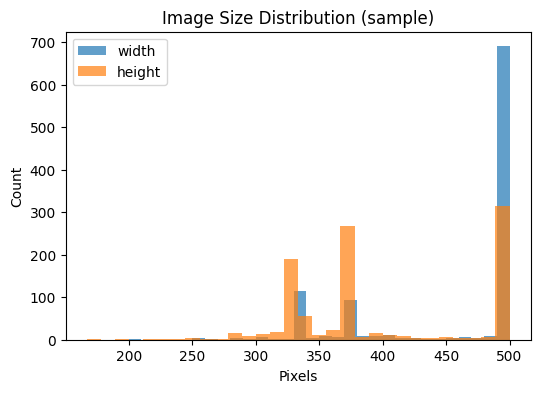

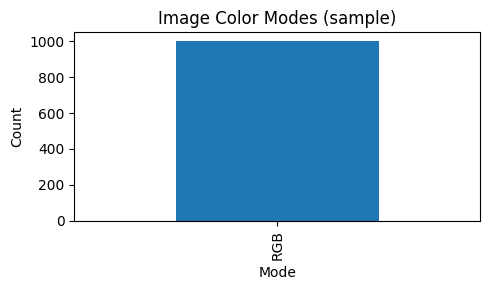

In [3]:
# Build image table from the dataset object created
dataset = Flickr8kImageDataset(image_dir=image_dir, transform=resnet_transforms)
df_image = pd.DataFrame(dataset.image_names, columns=['image_name'])
df_image['extension'] = df_image['image_name'].str.rsplit('.', n=1).str[-1].str.lower()

print(f'Total images in folder: {len(df_image)}')
display(df_image.head())
print('File extension distribution:')
display(df_image['extension'].value_counts())

# Image size and color mode statistics on a sample to keep EDA fast.
image_root = Path(image_dir)
sample_size = min(1000, len(df_image))
sample_names = df_image['image_name'].iloc[:sample_size].tolist()

sizes = []
modes = []
for name in sample_names:
    with Image.open(image_root / name) as im:
        sizes.append(im.size)
        modes.append(im.mode)

size_df = pd.DataFrame(sizes, columns=['width', 'height'])
print('Sample image size stats:')
display(size_df.describe())

plt.figure(figsize=(6, 4))
plt.hist(size_df['width'], bins=30, alpha=0.7, label='width')
plt.hist(size_df['height'], bins=30, alpha=0.7, label='height')
plt.title('Image Size Distribution (sample)')
plt.xlabel('Pixels')
plt.ylabel('Count')
plt.legend()
plt.show()

mode_counts = pd.Series(modes).value_counts()
plt.figure(figsize=(5, 3))
mode_counts.plot(kind='bar')
plt.title('Image Color Modes (sample)')
plt.xlabel('Mode')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
# Caption statistics.
captions_path = Path('dataset/captions.txt')
if not captions_path.exists():
    raise FileNotFoundError('Could not find captions file at dataset/captions.txt')

captions = pd.read_csv(captions_path, names=['image_name', 'caption'])
captions['caption'] = captions['caption'].astype(str)
captions['caption_len_words'] = captions['caption'].str.split().str.len()
captions['caption_len_chars'] = captions['caption'].str.len()

image_set = set(df_image['image_name'])
caption_image_set = set(captions['image_name'])
missing_from_images = sorted(caption_image_set - image_set)
missing_from_captions = sorted(image_set - caption_image_set)

print(f'Total captions: {len(captions)}')
print(f'Unique images in captions: {captions["image_name"].nunique()}')
print('Captions per image stats:')
display(captions.groupby('image_name').size().describe())
print(f'Image names in captions but missing from image folder: {len(missing_from_images)}')
print(f'Image names in image folder but missing from captions: {len(missing_from_captions)}')


Total captions: 40456
Unique images in captions: 8092
Captions per image stats:


count    8092.000000
mean        4.999506
std         0.044466
min         1.000000
25%         5.000000
50%         5.000000
75%         5.000000
max         5.000000
dtype: float64

Image names in captions but missing from image folder: 1
Image names in image folder but missing from captions: 0


Missing image name(s) referenced in captions:
['image']
Caption row(s) tied to missing image(s):


,image_name,caption,caption_len_words,caption_len_chars
0,image,caption,1,7


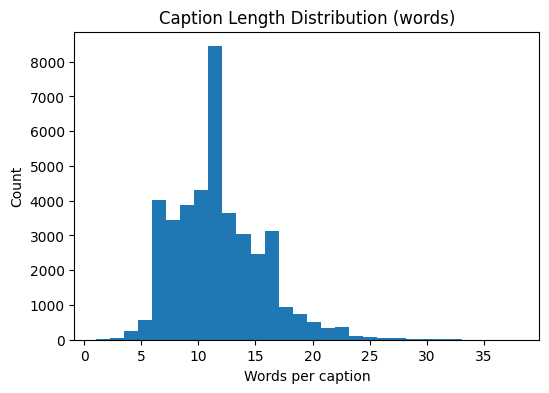

In [5]:
# Identify the exact missing filename(s) and related caption row(s).
if missing_from_images:
    print('Missing image name(s) referenced in captions:')
    print(missing_from_images)
    missing_caption_rows = captions[captions['image_name'].isin(missing_from_images)].copy()
    print('Caption row(s) tied to missing image(s):')
    display(missing_caption_rows)

plt.figure(figsize=(6, 4))
plt.hist(captions['caption_len_words'], bins=30)
plt.title('Caption Length Distribution (words)')
plt.xlabel('Words per caption')
plt.ylabel('Count')
plt.show()

,word,count
0,a,62986
1,.,36577
2,in,18974
3,the,18418
4,on,10743
5,is,9345
6,and,8851
7,dog,8136
8,with,7765
9,man,7265


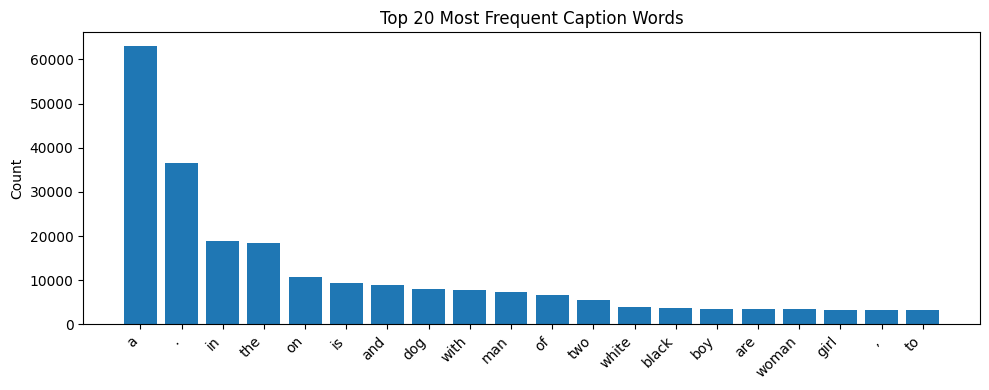

In [6]:
# Top frequent words (before punctuation cleaning).
all_words = []
for text in captions['caption']:
    all_words.extend(text.lower().split())
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])
display(top_words)

plt.figure(figsize=(10, 4))
plt.bar(top_words['word'], top_words['count'])
plt.title('Top 20 Most Frequent Caption Words')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2. Implement the baseline KNN model to get the baseline results. Using evaluation metrics like BLEU-4 and CIDER Scores

In [7]:
import numpy as np
import random
import torch.nn as nn
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Clean captions and keep only rows with existing images.
captions_clean = captions.copy()
captions_clean = captions_clean[captions_clean['image_name'] != 'image']
captions_clean = captions_clean[captions_clean['image_name'].isin(df_image['image_name'])].copy()

# Group captions by image for retrieval/evaluation.
captions_by_image = captions_clean.groupby('image_name')['caption'].apply(list).to_dict()
all_image_names = sorted(captions_by_image.keys())

print(f'Images with captions: {len(all_image_names)}')
print(f'Total cleaned caption rows: {len(captions_clean)}')

Using device: cuda
Images with captions: 8091
Total cleaned caption rows: 40455


In [8]:
# Build train/test image split for retrieval baseline.
train_names, test_names = train_test_split(
    all_image_names, test_size=0.2, random_state=SEED
)

print(f'Train images: {len(train_names)}')
print(f'Test images: {len(test_names)}')

Train images: 6472
Test images: 1619


In [9]:
# Download pre-trained frozen ResNet-50 model for feature extraction.

# ResNet50 feature extractor (2048-D global average pooled features).
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(device)
feature_extractor.eval()

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

class FeatureExtractionDataset(Dataset):
    def __init__(self, image_dir, image_names, transform):
        self.image_dir = Path(image_dir)
        self.image_names = image_names
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = self.image_dir / img_name
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        return img, img_name

@torch.no_grad()
def extract_features_in_batches(image_names, batch_size=None, num_workers=0):
    if batch_size is None:
        batch_size = 64 if device.type == 'cuda' else 16

    dataset = FeatureExtractionDataset(image_dir, image_names, resnet_transforms)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=(device.type == 'cuda')
    )

    all_features = []
    ordered_names = []

    for images, batch_names in loader:
        images = images.to(device, non_blocking=(device.type == 'cuda'))
        features = feature_extractor(images).flatten(start_dim=1).cpu().numpy().astype(np.float32)
        all_features.append(features)
        ordered_names.extend(batch_names)

    return np.vstack(all_features), ordered_names

feature_cache = Path('dataset/output/resnet50_knn_features.npz')
if feature_cache.exists():
    cache = np.load(feature_cache, allow_pickle=True)
    train_names = cache['train_names'].tolist()
    test_names = cache['test_names'].tolist()
    train_features = cache['train_features']
    test_features = cache['test_features']
    print(f'Loaded cached features from {feature_cache}')
else:
    train_features, train_names = extract_features_in_batches(train_names, batch_size=64, num_workers=0)
    test_features, test_names = extract_features_in_batches(test_names, batch_size=64, num_workers=0)
    np.savez(
        feature_cache,
        train_names=np.array(train_names, dtype=object),
        test_names=np.array(test_names, dtype=object),
        train_features=train_features,
        test_features=test_features
    )
    print(f'Saved features to {feature_cache}')

print('Feature matrix shapes:')
print('train_features:', train_features.shape)
print('test_features :', test_features.shape)

Loaded cached features from dataset\output\resnet50_knn_features.npz
Feature matrix shapes:
train_features: (6472, 2048)
test_features : (1619, 2048)


In [10]:
# k-NN retrieval baseline (k=1).
knn = NearestNeighbors(n_neighbors=1, metric='euclidean')
knn.fit(train_features)

distances, indices = knn.kneighbors(test_features)
predicted_image_names = [train_names[i[0]] for i in indices]

# Predicted caption for each test image: first caption from nearest train image.
predicted_captions = [captions_by_image[name][0] for name in predicted_image_names]
reference_captions = [captions_by_image[name] for name in test_names]

print('Sample retrieval pairs (test image -> nearest train image):')
for i in range(5):
    print(f'{test_names[i]} -> {predicted_image_names[i]} (dist={distances[i][0]:.4f})')

Sample retrieval pairs (test image -> nearest train image):
3139895886_5a6d495b13.jpg -> 3025546819_ce031d2fc3.jpg (dist=8.5608)
3133825703_359a0c414d.jpg -> 3145967309_b33abe4d84.jpg (dist=14.5322)
244910177_7c4ec3f65b.jpg -> 2251992614_0c601fae2c.jpg (dist=15.7236)
2127207912_9298824e66.jpg -> 191592626_477ef5e026.jpg (dist=13.2458)
1810651611_35aae644fb.jpg -> 2609900643_c07bcb0bae.jpg (dist=11.6776)


In [11]:
# BLEU-4 evaluation.
smooth = SmoothingFunction().method1
bleu4_scores_baseline = []
for refs, pred in zip(reference_captions, predicted_captions):
    ref_tokens = [r.lower().split() for r in refs]
    pred_tokens = pred.lower().split()
    score = sentence_bleu(
        ref_tokens, pred_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )
    bleu4_scores_baseline.append(score)

avg_bleu4 = float(np.mean(bleu4_scores_baseline))
print(f'Baseline k-NN BLEU-4: {avg_bleu4:.4f}')

Baseline k-NN BLEU-4: 0.0922


In [12]:
# CIDEr evaluation (requires pycocoevalcap).
# If package is missing, run: pip install pycocoevalcap
try:
    from pycocoevalcap.cider.cider import Cider

    gts = {i: reference_captions[i] for i in range(len(reference_captions))}
    res = {i: [predicted_captions[i]] for i in range(len(predicted_captions))}

    cider_scorer = Cider()
    cider_score_baseline, _ = cider_scorer.compute_score(gts, res)
    print(f'Baseline k-NN CIDEr: {cider_score_baseline:.4f}')
except Exception as e:
    print('CIDEr evaluation skipped (pycocoevalcap not available).')
    print('Error:', str(e))

Baseline k-NN CIDEr: 0.2563


### 3. Using Primary Model (CNN + RNN) that is trained and fine-tuned and evaluate using the same scores and metrics
Freeze all ResNet weights, train only attention + LSTM decoder and compare that model’s BLEU-4/CIDEr to your k-NN baseline

In [13]:
# --- Part 3: Primary Model (CNN + Attention LSTM) ---
import re
from collections import defaultdict

# 1) Text preprocessing + vocabulary
def clean_caption(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Use cleaned captions from the earlier dataframe
captions_cleaned = captions_clean.copy()
captions_cleaned["caption"] = captions_cleaned["caption"].apply(clean_caption)

# Build vocab with min frequency
min_freq = 5
max_len = 35
special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]

word_counts = Counter()
for cap in captions_cleaned["caption"]:
    word_counts.update(cap.split())

vocab_words = [w for w, c in word_counts.items() if c >= min_freq]
itos = special_tokens + sorted(vocab_words)
stoi = {w: i for i, w in enumerate(itos)}
pad_idx = stoi["<pad>"]
start_idx = stoi["<start>"]
end_idx = stoi["<end>"]
unk_idx = stoi["<unk>"]
vocab_size = len(itos)

print(f"Vocab size: {vocab_size}")

def encode_caption(text):
    tokens = text.split()
    tokens = tokens[: max_len - 2]
    seq = [start_idx] + [stoi.get(t, unk_idx) for t in tokens] + [end_idx]
    return seq

def pad_sequence(seq, max_len):
    if len(seq) < max_len:
        seq = seq + [pad_idx] * (max_len - len(seq))
    return seq[:max_len]

Vocab size: 2995


In [14]:
class CaptionDataset(Dataset):
    def __init__(self, image_dir, samples, transform):
        self.image_dir = Path(image_dir)
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, seq = self.samples[idx]
        img_path = self.image_dir / img_name
        if not img_path.exists():
            raise FileNotFoundError(f'Image not found: {img_path}')
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        caption = torch.tensor(seq, dtype=torch.long)
        return image, caption, img_name

# Build train/val/test caption samples (image_name, token_id_sequence).
train_image_names, val_image_names = train_test_split(
    train_names, test_size=0.1, random_state=SEED
 )

def build_samples(image_names):
    samples = []
    subset = captions_cleaned[captions_cleaned["image_name"].isin(image_names)]
    for _, row in subset.iterrows():
        seq = pad_sequence(encode_caption(row["caption"]), max_len)
        samples.append((row["image_name"], seq))
    return samples

train_samples = build_samples(train_image_names)
val_samples = build_samples(val_image_names)
test_samples = build_samples(test_names)

print(f"Train samples: {len(train_samples)}")
print(f"Val samples: {len(val_samples)}")
print(f"Test samples: {len(test_samples)}")

def collate_fn(batch):
    images, captions, names = zip(*batch)
    images = torch.stack(images, dim=0)
    captions = torch.stack(captions, dim=0)
    lengths = (captions != pad_idx).sum(dim=1)
    return images, captions, lengths, list(names)

batch_size = 32 if device.type == "cuda" else 16
train_loader = DataLoader(
    CaptionDataset(image_dir, train_samples, resnet_transforms),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    CaptionDataset(image_dir, val_samples, resnet_transforms),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    CaptionDataset(image_dir, test_samples, resnet_transforms),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

Train samples: 29120
Val samples: 3240
Test samples: 8095


In [15]:
# 3) Class-based Encoder + Attention + LSTM Decoder
class EncoderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        modules = list(backbone.children())[:-2]
        self.cnn = nn.Sequential(*modules)
        self.out_dim = 2048

    def forward(self, images):
        features = self.cnn(images)
        b, c, h, w = features.size()
        features = features.permute(0, 2, 3, 1).contiguous()
        features = features.view(b, h * w, c)
        return features

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class DecoderLSTM(nn.Module):
    def __init__(self, vocab_size, encoder_dim=2048, embed_dim=256,
                 decoder_dim=512, attention_dim=256, dropout=0.5):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.lstm = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

    def init_hidden_state(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)
        h = self.init_h(mean_enc)
        c = self.init_c(mean_enc)
        return h, c

    def forward(self, encoder_out, captions):
        b = encoder_out.size(0)
        seq_len = captions.size(1)
        embeddings = self.embed(captions)
        h, c = self.init_hidden_state(encoder_out)

        outputs = torch.zeros(b, seq_len, vocab_size, device=encoder_out.device)
        for t in range(seq_len):
            context, _ = self.attention(encoder_out, h)
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.lstm(lstm_input, (h, c))
            out = self.fc(self.dropout(h))
            outputs[:, t, :] = out
        return outputs

encoder = EncoderCNN().to(device)
decoder = DecoderLSTM(vocab_size=vocab_size).to(device)

# Stage 1: freeze encoder parameters
for p in encoder.parameters():
    p.requires_grad = False

In [16]:
# 4) Training setup with Automatic Mixed Precision (AMP)
import torch.amp as amp

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
decoder_params = list(decoder.parameters())
optimizer = torch.optim.Adam(decoder_params, lr=1e-3)

# GradScaler enables AMP on CUDA; is a no-op on CPU
scaler = amp.GradScaler(enabled=(device.type == 'cuda'))

print(f"Training device : {device}")
print(f"AMP enabled     : {device.type == 'cuda'}")


Training device : cuda
AMP enabled     : True


In [17]:
# 5) Training loop with Automatic Mixed Precision and gradient clipping

def run_epoch(loader, train=True):
    if train:
        decoder.train()
        encoder.train() if any(p.requires_grad for p in encoder.parameters()) else encoder.eval()
    else:
        decoder.eval()
        encoder.eval()

    total_loss, total_tokens = 0.0, 0

    for images, captions, lengths, _ in loader:
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        inputs  = captions[:, :-1]
        targets = captions[:, 1:].reshape(-1)

        if train:
            optimizer.zero_grad(set_to_none=True)   # faster than zero_grad()

        with torch.set_grad_enabled(train):
            with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                encoder_out = encoder(images)
                outputs     = decoder(encoder_out, inputs)
                loss        = criterion(outputs.reshape(-1, vocab_size), targets)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(
                    [p for p in list(decoder.parameters()) + list(encoder.parameters())
                     if p.requires_grad],
                    max_norm=5.0
                )
                scaler.step(optimizer)
                scaler.update()

        num_tokens   = (targets != pad_idx).sum().item()
        total_loss  += loss.item() * num_tokens
        total_tokens += num_tokens

    return total_loss / max(1, total_tokens)


Epoch 1/5  train loss: 3.6336  val loss: 3.0918
Epoch 2/5  train loss: 2.8767  val loss: 2.9021
Epoch 3/5  train loss: 2.5791  val loss: 2.8461
Epoch 4/5  train loss: 2.3582  val loss: 2.8291
Epoch 5/5  train loss: 2.1772  val loss: 2.8376


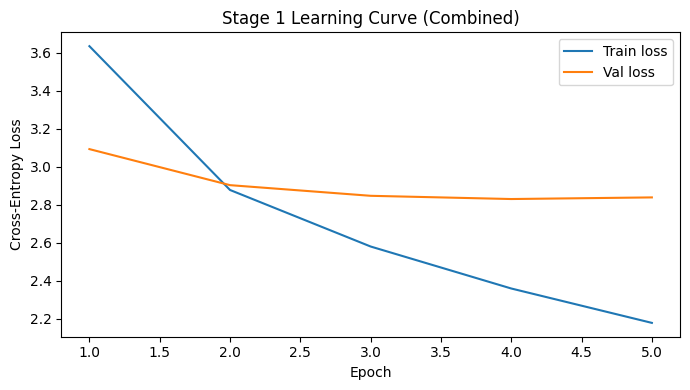

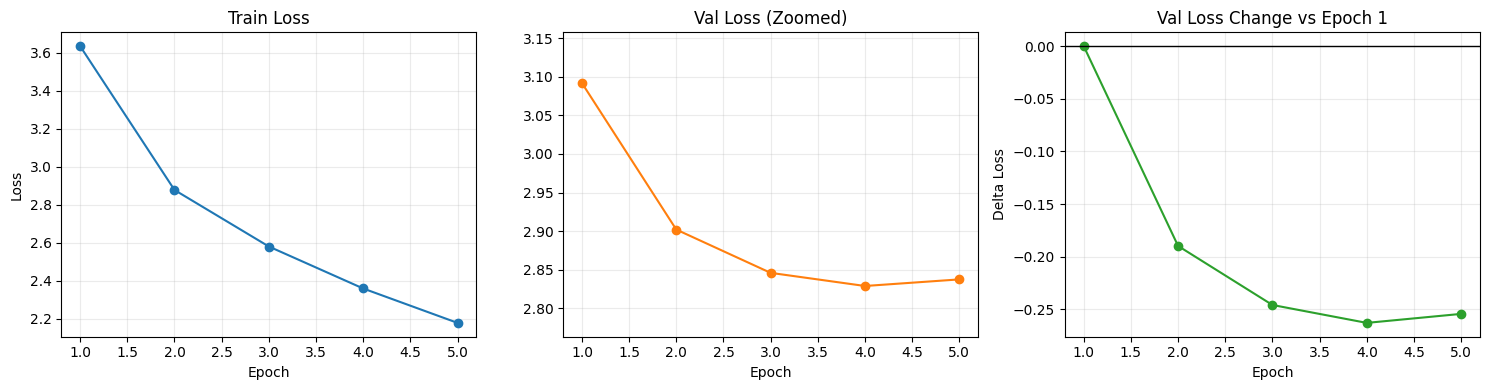

In [18]:
# 6) Stage 1 training — encoder frozen, decoder only
epochs = 5
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}/{epochs}  train loss: {train_loss:.4f}  val loss: {val_loss:.4f}")

# Figure A: original combined view
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_losses, label='Train loss')
plt.plot(range(1, epochs + 1), val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Stage 1 Learning Curve (Combined)')
plt.legend()
plt.tight_layout()
plt.show()

# Figure B: separated/zoomed views for validation trend clarity
epochs_axis = np.arange(1, epochs + 1)
val_arr = np.array(val_losses)
val_delta = val_arr - val_arr[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_axis, train_losses, marker='o', color='tab:blue')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.25)

axes[1].plot(epochs_axis, val_losses, marker='o', color='tab:orange')
axes[1].set_title('Val Loss (Zoomed)')
axes[1].set_xlabel('Epoch')
val_min, val_max = float(val_arr.min()), float(val_arr.max())
pad = max(0.005, (val_max - val_min) * 0.25)
axes[1].set_ylim(val_min - pad, val_max + pad)
axes[1].grid(alpha=0.25)

axes[2].plot(epochs_axis, val_delta, marker='o', color='tab:green')
axes[2].axhline(0.0, color='black', linewidth=1)
axes[2].set_title('Val Loss Change vs Epoch 1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Delta Loss')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

FT Epoch 1/3  train loss: 2.1482  val loss: 2.8121
FT Epoch 2/3  train loss: 1.9895  val loss: 2.8142
FT Epoch 3/3  train loss: 1.9070  val loss: 2.8099


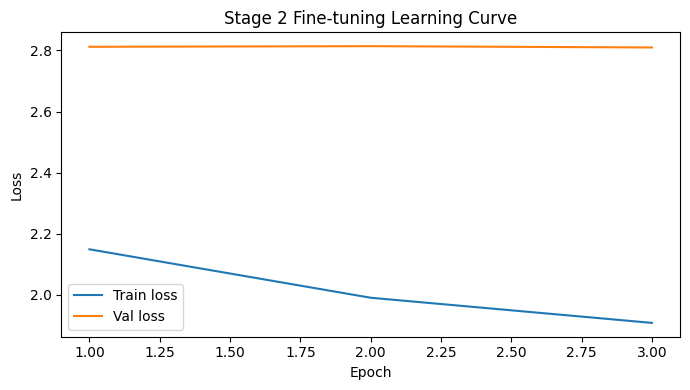

In [19]:
# 7) Stage 2 fine-tuning — unfreeze last ResNet block and train at lower LR
required = [
    'encoder', 'decoder', 'run_epoch', 'train_loader', 'val_loader',
    'device', 'amp', 'torch'
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        'Stage 2 prerequisites missing: ' + ', '.join(missing) +
        '. Run Cells 17 to 22 first (model/data/training setup + Stage 1).'
    )

def unfreeze_last_block(model):
    for name, param in model.cnn.named_parameters():
        if name.startswith("7."):
            param.requires_grad = True

unfreeze_last_block(encoder)
optimizer = torch.optim.Adam(
    list(decoder.parameters()) + [p for p in encoder.parameters() if p.requires_grad],
    lr=1e-4
)
# Reset scaler for fine-tuning stage
scaler = amp.GradScaler(enabled=(device.type == 'cuda'))

ft_epochs = 3
ft_train_losses, ft_val_losses = [], []

for epoch in range(1, ft_epochs + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    print(f"FT Epoch {epoch}/{ft_epochs}  train loss: {train_loss:.4f}  val loss: {val_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, ft_epochs + 1), ft_train_losses, label='Train loss')
plt.plot(range(1, ft_epochs + 1), ft_val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Stage 2 Fine-tuning Learning Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# 8) Decoding helpers

required = ['decoder', 'start_idx', 'end_idx', 'pad_idx', 'itos', 'torch']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        'Decoding prerequisites missing: ' + ', '.join(missing) +
        '. Run Cells 17 to 23 first.'
    )

@torch.no_grad()
def greedy_decode(encoder_out, max_len=35):
    b = encoder_out.size(0)
    h, c = decoder.init_hidden_state(encoder_out)
    word = torch.full((b,), start_idx, dtype=torch.long, device=encoder_out.device)
    captions_out = [[] for _ in range(b)]
    finished = torch.zeros(b, dtype=torch.bool, device=encoder_out.device)

    for _ in range(max_len):
        emb = decoder.embed(word)
        context, _ = decoder.attention(encoder_out, h)
        lstm_input = torch.cat([emb, context], dim=1)
        h, c = decoder.lstm(lstm_input, (h, c))
        scores = decoder.fc(h)
        word = scores.argmax(dim=1)

        for i in range(b):
            if not finished[i]:
                token = word[i].item()
                captions_out[i].append(token)
                if token == end_idx:
                    finished[i] = True

        if finished.all():
            break

    return captions_out

def decode_tokens(tokens):
    words = []
    for t in tokens:
        if t == end_idx:
            break
        if t in (start_idx, pad_idx):
            continue
        words.append(itos[t] if t < len(itos) else "<unk>")
    return " ".join(words)

In [21]:
# 9) Evaluate BLEU-4 and CIDEr on test set
required = [
    'encoder', 'decoder', 'test_names', 'captions_by_image',
    'image_dir', 'resnet_transforms', 'device', 'DataLoader', 'Dataset',
    'SmoothingFunction', 'sentence_bleu', 'np', 'clean_caption',
    'greedy_decode', 'decode_tokens', 'max_len', 'Path', 'Image'
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        'Evaluation prerequisites missing: ' + ', '.join(missing) +
        '. Run Cells 3 to 24 in order first.'
    )

# Evaluate once per unique test image (avoids duplicate weighting from caption-level samples).
unique_test_names = sorted(set(test_names))

class EvalImageDataset(Dataset):
    def __init__(self, image_dir, image_names, transform):
        self.image_dir = Path(image_dir)
        self.image_names = image_names
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = self.image_dir / img_name
        if not img_path.exists():
            raise FileNotFoundError(f'Image not found: {img_path}')
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        return image, img_name

eval_batch_size = batch_size if 'batch_size' in globals() else (32 if device.type == 'cuda' else 16)
eval_loader = DataLoader(
    EvalImageDataset(image_dir, unique_test_names, resnet_transforms),
    batch_size=eval_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

encoder.eval()
decoder.eval()

generated = []
references = []

for images, names in eval_loader:
    images = images.to(device, non_blocking=True)
    with torch.no_grad():
        with torch.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            enc = encoder(images)
            pred_tokens = greedy_decode(enc, max_len=max_len)

    for i, img_name in enumerate(names):
        generated.append(decode_tokens(pred_tokens[i]))
        if img_name not in captions_by_image:
            raise KeyError(f'Image {img_name} not found in captions_by_image. Check split alignment.')
        refs = captions_by_image[img_name]
        references.append([clean_caption(r) for r in refs])

print(f'Evaluated unique test images: {len(generated)}')

# BLEU-4
smooth = SmoothingFunction().method1
bleu4_scores_primary = []
for refs, pred in zip(references, generated):
    ref_tokens = [r.split() for r in refs]
    pred_tokens = pred.split()
    score = sentence_bleu(
        ref_tokens, pred_tokens,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smooth
    )
    bleu4_scores_primary.append(score)

print(f"Primary model BLEU-4: {float(np.mean(bleu4_scores_primary)):.4f}")

try:
    from pycocoevalcap.cider.cider import Cider
    gts = {i: references[i] for i in range(len(references))}
    res = {i: [generated[i]] for i in range(len(generated))}
    cider_scorer = Cider()
    cider_score_primary, _ = cider_scorer.compute_score(gts, res)
    print(f"Primary model CIDEr: {cider_score_primary:.4f}")
except Exception as e:
    print('CIDEr evaluation skipped (pycocoevalcap not available).')
    print('Error:', str(e))

Evaluated unique test images: 1619
Primary model BLEU-4: 0.1874
Primary model CIDEr: 0.5715
